# Demostration : Ramp layer example

In [1]:
# systems operations
# import subprocess
# import sys

# track time of process
import time

# meshing
import gmsh

# math
import numpy as np

# graphics
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# set default font size in plots
plt.rcParams.update({'font.size': 20})
%matplotlib inline

# plotting violin plots 
import pandas as pd 
import seaborn as sns



## Importing local scripts and libraries into notebook


In [2]:
%reload_ext autoreload
%autoreload 2
import tritime2d as tt

## Create Mesh using GMSH
### Input parameters
**v1** : velocity in first layer 
**v2** : velocity in second layer 

**sx**,**sz** : position of source

**bx**,**bz** : width and depth of computational domain 

**layer_depth** : depth to layer 

**theta** : slope of layer

**lcar** : mesh spacing at boundaries 

**lay_car** : mesh spacing along boundary of layer

**scar** : mesh spacing at source


The source depth must be inside the computational area (i.e. 0 < sx < bx & 0 < sz < bz) as should the layer ( 0 < layer_depth < bz )

In [3]:
v1 = 1000.0
v2 = 3000.0


sx = 500.0 
sz = 500.0 

bx = 10000.0 
bz = 5000.0

layer_depth = bz/3

# theta = 30.*np.pi/180
phi = 10.*np.pi/180

ramp_length = bx/3


# resolution 
lcar = 50.0
lay_car = lcar  
scar = lcar 
layer_v = np.append(v1,v2)


In [4]:
# check that ramp finishes within layer 
ramp_height = ramp_length*np.tan(phi)
ramp_up_x = bx/2-ramp_length/2
ramp_down_x = bx/2+ramp_length/2

# function to calculate depth to layer interface for any x position 
def layer_d(x):
    return np.where(x <= ramp_up_x,
                    layer_depth,
                    np.where(x >= ramp_down_x,
                             layer_depth + ramp_height,
                             layer_depth + (x - ramp_up_x) * np.tan(phi)))

In [5]:
print('Ramp height:', ramp_height)
print('Ramp length:', ramp_length)
print ('Ramp extents from x=', ramp_up_x, ' to x=', ramp_down_x)
print('depth variation of layer',layer_d(400),layer_d(7000))


Ramp height: 587.75660236155
Ramp length: 3333.3333333333335
Ramp extents from x= 3333.333333333333  to x= 6666.666666666667
depth variation of layer 1666.6666666666667 2254.423269028217


In [6]:
gmsh.initialize()
gmsh.model.add("Two Layer Ramp Model")

In [ ]:
nlayers = 2
layer_v = np.append(v1,v2)
# add points
p2 = gmsh.model.geo.addPoint( 0,    0, 0, lcar, 1)
p3 = gmsh.model.geo.addPoint(bx,    0, 0, lcar, 2)
p4 = gmsh.model.geo.addPoint(bx,  layer_depth+ramp_height, 0, lay_car, 3)
p5 = gmsh.model.geo.addPoint(bx, bz, 0, lcar, 4)
p6 = gmsh.model.geo.addPoint( 0.0, bz, 0, lcar, 5)
p7 = gmsh.model.geo.addPoint( 0.0,  layer_depth, 0, lay_car, 6)

p8 = gmsh.model.geo.addPoint( ramp_up_x,  layer_depth, 0, lay_car, 7)
p9 = gmsh.model.geo.addPoint( ramp_down_x,  layer_depth+ramp_height, 0, lay_car, 8)

# s1 = gmsh.model.geo.addPoint( sx,  sz, 0, lay_car, 7)
s1 = gmsh.model.geo.addPoint( sx,  sz, 0, scar, 9)
# add lines

l23 = gmsh.model.geo.addLine(p2, p3, 23)
l34 = gmsh.model.geo.addLine(p3, p4, 34)
l45 = gmsh.model.geo.addLine(p4, p5, 45)
l56 = gmsh.model.geo.addLine(p5, p6, 56)
l67 = gmsh.model.geo.addLine(p6, p7, 67)
l72 = gmsh.model.geo.addLine(p7, p2, 72)

l78 = gmsh.model.geo.addLine(p7, p8, 78) 
l89 = gmsh.model.geo.addLine(p8, p9, 89) 
l94 = gmsh.model.geo.addLine(p9, p4, 94)

# curve loop
gmsh.model.geo.addCurveLoop([l23, l34, -l94, -l89,-l78,l72], 1)
gmsh.model.geo.addCurveLoop([l45, l56, l67, l78,l89,94], 2)


# loop over surfaces to be added  
for l in range(1, 3):
    print(l)
    gmsh.model.geo.addPlaneSurface([l], l)

# synchronize before adding point
gmsh.model.geo.synchronize()

if (sz < layer_d(sx)):   # need a better condition here as layer depth varies with distance ..... 
    gmsh.model.mesh.embed(0, [9], 2, 1) # embed a point 9 (dim 0) which is node 1 in a surface (i.e. dim 2) entitled 1 
else:
    gmsh.model.mesh.embed(0, [9], 2, 2) # embed a point 9 (dim 0) which is node 1 in a surface (i.e. dim 2) entitled 2 

# give the surfaces physical values 
for l in range(1, nlayers+1):
    print(l)
    gmsh.model.addPhysicalGroup(2,[l],l)    

# gmsh.option.setNumber("Mesh.Algorithm", 8)  # 8 tries to impliment a regular mesh
gmsh.option.setNumber("Mesh.Algorithm", 5)  # Delaunay

mesh = gmsh.model.mesh.generate(2)   # put as 2 as we are generating a 2d mesh 


# write mesh to file 
# gmsh.write("test.vtk")

# Clear existing model
# gmsh.finalize()   # doing this will mean that you lose the mesh 


1
2
1
2
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 23 (Line)
Info    : [ 20%] Meshing curve 34 (Line)
Info    : [ 30%] Meshing curve 45 (Line)
Info    : [ 40%] Meshing curve 56 (Line)
Info    : [ 50%] Meshing curve 67 (Line)
Info    : [ 60%] Meshing curve 72 (Line)
Info    : [ 70%] Meshing curve 78 (Line)
Info    : [ 80%] Meshing curve 89 (Line)
Info    : [ 90%] Meshing curve 94 (Line)
Info    : Done meshing 1D (Wall 0.000571218s, CPU 0.000852s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Delaunay)
Info    : [ 60%] Meshing surface 2 (Plane, Delaunay)
Info    : Done meshing 2D (Wall 0.42058s, CPU 0.421695s)
Info    : 26884 nodes 53977 elements
Info    : Writing 'test.vtk'...
Info    : Done writing 'test.vtk'


### Extract the Nodes and Elements from the mesh


In [9]:
x, y, z, cells, cell_type = tt.extract_mesh()

In [10]:
cell_vel =  tt.velocity_by_layer(cell_type, layer_v)

## Calculate theoretical traveltimes 

In [11]:
#
#  Calculate theoretical travel times on ramp 
#
infinity = 10**20
ddx = 1

theta_c  = np.arcsin(v1/v2)
theo_time = np.zeros(len(y))
m_ray = -np.tan(np.pi/2.-theta_c-phi)
m_border = np.tan(phi) # ramp_height/(ramp_up_x-ramp_down_x) #
c_border = layer_depth - ramp_up_x*m_border

x1 = sx+(layer_depth-sz)*np.tan(theta_c)    # critical ray arrives at interface 


for i in range(len(y)):
    if y[i] <= layer_d(x[i]):           # top layer
        # direct wave
        theo_time[i] = np.sqrt((x[i]-sx)**2+(y[i]-sz)**2)/v1
        # conic wave
        x1 = sx+(layer_depth-sz)*np.tan(theta_c)    # critical ray arrives at interface 
        
        xc1 = x[i]+(y[i]-layer_depth)*np.tan(theta_c)    # if take off is at top of of ramp  
        yc1 = layer_depth
        
        xc2 = (y[i]- m_ray*x[i]-c_border)/(m_border-m_ray)    # if takeoff point is on ramp 
        yc2 = m_border*xc2+c_border
    
        xc3 = x[i] + (y[i]-layer_depth-ramp_height)*np.tan(theta_c)   # if takeoff is on below ramp
        yc3 = layer_depth+ramp_height
        
        c1 = (layer_depth-sz)*np.tan(theta_c)
        c2  = (layer_depth-y[i])*np.tan(theta_c)
        if xc1 <=  ramp_up_x : # before the ramp  
            if np.abs(x[i]-sx) > c1+c2:
                conic_time = (2*layer_depth-sz-y[i])/v1/np.cos(theta_c)+(np.abs(x[i]-sx)-c1-c2)/v2  # +(np.abs(x[i]-sx)-x1-x2)/v2 #                 

                if conic_time < theo_time[i]:
                    theo_time[i] = conic_time     
        else: 
            conic_time_ramp = infinity 
            if xc2 >= ramp_up_x and xc2 <= ramp_down_x:
                conic_time_ramp = (layer_d(sx)-sz)/v1/np.cos(theta_c)+np.abs(layer_d(xc2)-y[i])/v1/np.cos(theta_c+phi)+   \
                    (ramp_up_x-x1+np.sqrt((xc2-ramp_up_x)**2+(layer_d(xc2)-layer_d(ramp_up_x))**2))/v2            

            conic_time_flat = infinity 
            if xc3 >= ramp_down_x:
                conic_time_flat = (2*layer_depth+ramp_height-sz-y[i])/v1/np.cos(theta_c)+    \
                         (ramp_up_x-x1+xc3-ramp_down_x+                            \
                           np.sqrt((ramp_down_x-ramp_up_x)**2+(ramp_height)**2) )/v2
            
            conic_time = np.min([conic_time_ramp,conic_time_flat])
            if conic_time < theo_time[i]:
                theo_time[i] = conic_time        
        # account for 1st diffraction point at top of ramp 
        x_diff = ramp_up_x
        z_diff = layer_d(x_diff)
        primary_time = np.abs(z_diff-sz)/v1/np.cos(theta_c) + np.abs(x_diff-x1)/v2
        secondary_time = np.sqrt((x[i]-x_diff)**2+(y[i]-z_diff)**2)/v1
        tmin = primary_time + secondary_time
        if tmin < theo_time[i] :
            theo_time[i] = tmin
            # print('diffraction point  #1')
            
            
        # account for 2nd diffraction point at bottom of ramp 
        x_diff = ramp_down_x
        z_diff = layer_depth+ramp_height
        
        primary_time = primary_time+np.sqrt((ramp_down_x-ramp_up_x)**2+(ramp_height)**2)/v2
        secondary_time = np.sqrt((x[i]-x_diff)**2+(y[i]-z_diff)**2)/v1
        tmin = primary_time+secondary_time
        if tmin < theo_time[i] :
            theo_time[i] = tmin   
            print('diffraction point  #2')
                       
    else:           # bottom layer and interface
            
        if (y[i] < m_border*x[i]+c_border) : # stop rays traveling through ramp interface 
            x_diff = ramp_down_x
            z_diff = layer_depth+ramp_height
            x1 = sx+(layer_depth-sz)*np.tan(theta_c)    # critical ray arrives at interface 

            # account for 2nd diffraction point at bottom of ramp 
            primary_time = np.abs(layer_d(x1)-sz)/v1/np.cos(theta_c) + np.abs(ramp_up_x-x1)/v2   \
                          +np.sqrt((ramp_down_x-ramp_up_x)**2+(ramp_height)**2)/v2
            secondary_time = np.sqrt((x[i]-x_diff)**2+(y[i]-z_diff)**2)/v2
            tmin = primary_time+secondary_time
            # if tmin < theo_time[i] :
            theo_time[i] = tmin
            # print('using diffraction point',x[i],z[i])
            if np.abs(y[i]- z_diff) < 0.001 :
                if np.abs(x[i]-x_diff) < 0.001:
                    print('theory',x[i],theo_time[i])
                    print('tri,theory,theory-tri',x[i],tri_time[i],theo_time[i],theo_time[i]-tri_time[i])
        else:    
            # refracted wave
            x_cross = sx
            #  tmin = np.sqrt((X[i]-sx)**2+(Z[i]-layer_d(X[i]))**2)/v2+(layer_d(X[i]-x_cross)-sz)/v1
            tmin = infinity
            not_found = True
            while (not_found):
                t_test = np.sqrt((x[i]-x_cross)**2+(y[i]-layer_d(x_cross))**2)/v2 + \
                        np.sqrt((x_cross-sx)**2+(layer_d(x_cross)-sz)**2)/v1         # upper layer traveltime
                if x[i] >= sx:
                    x_cross = x_cross+ddx
                else:
                    x_cross = x_cross-ddx                    
                if x_cross > ramp_up_x :
                    theo_time[i] = infinity 
                    print('exiting because x_cross too large')
                    break
                if t_test < tmin:
                    tmin = t_test                
                else:
                    not_found = False
                    theo_time[i] = tmin

            # account for 1st diffraction point at top of ramp 
            x_diff = ramp_up_x
            z_diff = layer_d(x_diff)
                
            x1 = sx+(layer_depth-sz)*np.tan(theta_c)    # critical ray arrives at interface 
            primary_time = np.abs(z_diff-sz)/v1/np.cos(theta_c) + np.abs(x_diff-x1)/v2
            secondary_time = np.sqrt((x[i]-x_diff)**2+(y[i]-z_diff)**2)/v2
            tmin = primary_time + secondary_time
            if tmin < theo_time[i] :
                theo_time[i] = tmin        



## Assign initial travel time 
**Note:** If doing this manually, set non-source nodes to 1.e32 to get fastest computational times

In [13]:
initial_time = tt.init_traveltime(sx, sz, x, y, cells, cell_vel) 

Source location [500.0, 500.0], source is in cell 6583
Initial travel time on starting cell: [0.         0.0513769  0.03731416]
Source located at a single node


## Set diffraction points 
- We will check two locations for diffraction: the top and bottom corner of the ramp

In [14]:
diff_nodes = np.zeros(len(x))
for i in range(len(x)):
    if (np.abs(x[i]-ramp_up_x)<0.001) and (np.abs(y[i]-layer_depth)<0.001):
        diff_nodes[i] = 1
    if (np.abs(x[i]-ramp_down_x)<0.001) and (np.abs(y[i]-layer_depth-ramp_height)<0.001):
        diff_nodes[i] = 1

### Plot input model and analytical solution  
We plot the mesh, the defined diffraction points and source location. Contours of the analytical solution are plotted as contours 

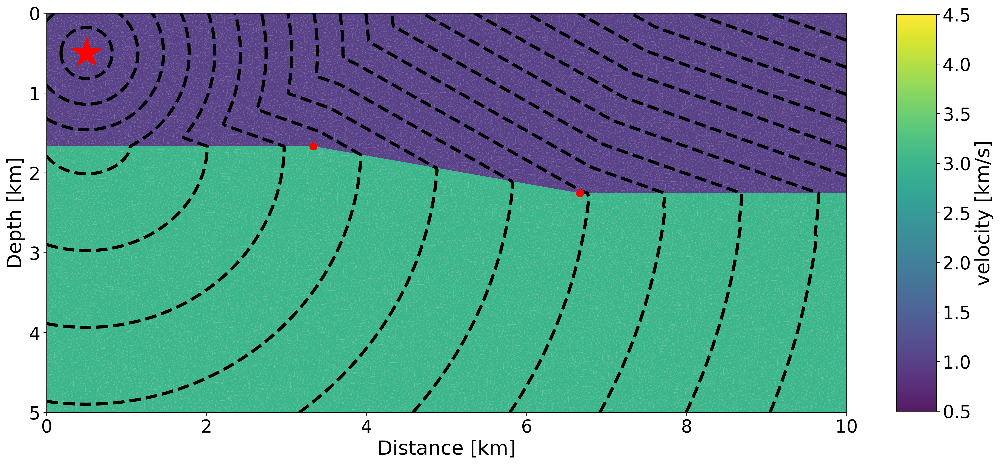

In [15]:
kilo = 1000 

patches = []
for i in range(len(cells)):
    idx = cells[i]
    poly_pts = np.transpose(np.vstack((x[idx]/kilo,y[idx]/kilo)))
    polygon = Polygon(poly_pts)
    patches.append(polygon)


fig, ax = plt.subplots(figsize=(20,20), dpi=300)  
p = PatchCollection(patches, alpha=0.9,edgecolor='none', cmap='viridis')
p.set_array(cell_vel/kilo)
p.set_clim(vmin=0.5, vmax=4.5)  # Set your desired min/max values here

ax.add_collection(p)
plt.scatter(sx/kilo, sz/kilo, c='red', s=1200, marker='*', label='Source',zorder=2, clip_on=False)

max_time = max(theo_time)
min_time = min(theo_time)
ncontours = 20
dc = (max_time-min_time)/ncontours
levels = np.arange(min_time, max_time+dc,dc )

# plot figure 
tcf_tri = plt.tricontour(x/kilo, y/kilo, theo_time,levels = levels, colors='k',linestyles='--',linewidths=3.5)

mask = diff_nodes > 0
if mask.any():
    plt.scatter(x[mask]/kilo, y[mask]/kilo, s=250, c='r', marker='.', zorder=5, label='Diffraction nodes')

cbar = fig.colorbar(p, ax=ax,shrink=0.4, aspect=10, pad=0.05)
cbar.set_label('velocity [km/s]',fontsize=22)

plt.xlim(np.min(x/kilo),np.max(x/kilo)) 
plt.ylim(np.max(y/kilo),np.min(y/kilo)) # flip axis for depth
ax.set_aspect('equal')

ax.set_xlabel(r'Distance [km]',fontsize=22)
ax.set_ylabel(r'Depth [km]',fontsize=22)

plt.show()

In [16]:
print('In TriTime2d, no. of cells:', len(cell_vel), ' no. of nodes:', len(x))

In TriTime2d, no. of cells: 53164  no. of nodes: 26884


## Run TriTime2d

In [44]:
start=time.time()
traveltime = tt.tritime2d(x, y, z, cells, cell_vel, initial_time, diff_nodes, fast=False)
end=time.time()
print(end-start)

 starting trilateration.....
 first traveltime computation 
 diffraction points considered               7
 next traveltime computation 
 diffraction points considered               8
 next traveltime computation 
 diffraction points considered               0
0.08264398574829102


Compare traveltime estimation with theoretical value 

In [23]:
mask = theo_time > 0.

safe_time = np.where(mask, theo_time, 1.)  # replace 0s with 1 to avoid divide-by-zero
Tri_Theo_diff = np.where(mask, (traveltime - theo_time) / safe_time * 100, 0.)

In [24]:
# Delineate velocity boundary for plotting 
xx = np.arange(0,10000)
dd = layer_d(xx)


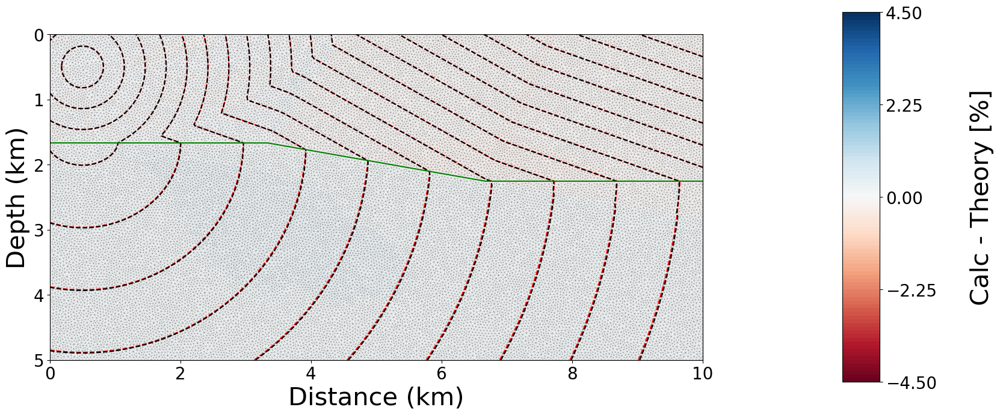

In [25]:
kilo = 1000. 
# c_range = np.max(np.max((abs(np.max(Tri_Theo_diff)),abs(np.min(Tri_Theo_diff)))))
c_range = 4.5

dcc = (2*c_range)/100
clevels=np.arange(-c_range,c_range+dcc,dcc )

max_time = max(traveltime)
min_time = min(traveltime)
ncontours = 20
dc = (max_time-min_time)/ncontours
levels = np.arange(min_time, max_time+dc,dc )


# plot figure 
fig = plt.figure(figsize=(20,20))
ax1 = plt.axes()
ax1.set_aspect('equal')

plt.triplot(x/kilo, y/kilo, cells, color='black', linewidth=0.1, zorder=2)
tcf_tri  = plt.tricontour( x/kilo, y/kilo, traveltime, levels=levels, colors='r', linestyles='--', zorder=2)
tcf_theo = plt.tricontour( x/kilo, y/kilo, theo_time,  levels=levels, colors='k', linestyles='--', zorder=2)
cc       = plt.tricontourf(x/kilo, y/kilo, Tri_Theo_diff, clevels, cmap='RdBu', zorder=1)

plt.plot(xx/kilo,dd/kilo,color='green')


plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Distance (km)',fontsize=30)
plt.ylabel('Depth (km)',fontsize=30)

# Color bar
tticks = np.linspace(-c_range, c_range, 5, endpoint=True)
cb=plt.colorbar(cc,shrink=0.4, aspect=10, pad=0.15,ticks=tticks)
cb.ax.tick_params(axis='both', which='major', labelsize=20)
cb.set_label('Calc - Theory [%]', fontsize=30, rotation=90, labelpad=40)
ax1.invert_yaxis()


# fig.tight_layout()
plt.show()

Plot error distribution

In [27]:
print('error range:    ',np.max(Tri_Theo_diff),np.min(Tri_Theo_diff) ,'%')

error range:     0.21152197409890888 -0.21767299723814051 %


In [28]:
# Create categories
categories = (['TriTime'] * len(Tri_Theo_diff))

# Combine the data
values = np.concatenate([Tri_Theo_diff])

# Create the DataFrame
df = pd.DataFrame({'Solver': categories, 'Error': values})

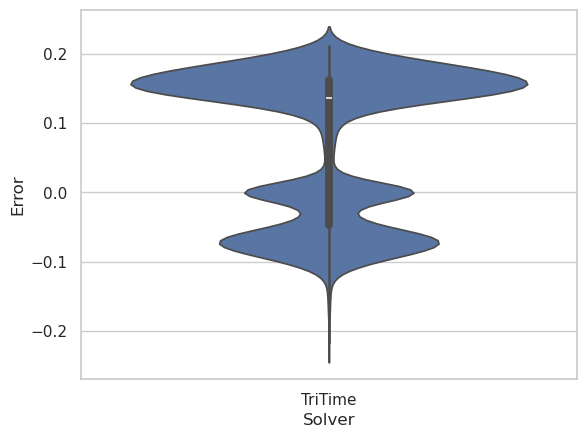

In [29]:
sns.set_theme(style="whitegrid")
ax = sns.violinplot(x="Solver", y="Error",data=df, hue="Solver",legend=False)


Write out results in a vtk file that can be read by paraview

In [ ]:
write_vtk(x, y, z, cells, cell_vel, traveltime, "Ramp_Layer_Case.vtk")